# Project: House Price Prediction (Regression)

**Project Objective:** Build a regression model that accurately predicts the sale price of houses based on a large number of features, covering the complete ML workflow — from EDA to advanced preprocessing, feature engineering, model training, and evaluation.

---

## Step 1: Setup — Importing Libraries

In [1]:
# !pip install -q scikit-learn
# !pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import os

# Set plot style
sns.set_style('whitegrid')

## Step 2: Data Loading via Kaggle API
We load the data directly from the Kaggle competition.

In [8]:
import os
import shutil

# Place your 'kaggle.json' file in the same folder as this notebook.
# 1. https://www.kaggle.com/settings/account
# 2. “Create New API Token”
# 3. Download kaggle.json
# 4. Move it to your notebook folder (same directory as .ipynb)
src = 'kaggle.json'
dest_dir = os.path.expanduser('~/.kaggle')
dest = os.path.join(dest_dir, 'kaggle.json')

os.makedirs(dest_dir, exist_ok=True)

if os.path.exists(src):
    shutil.copy(src, dest)
    os.chmod(dest, 0o600)
    print('Kaggle API key copied and permissions set correctly.')
else:
    print('Error: kaggle.json not found.')

!kaggle --version
print('\nKaggle API configured successfully')

Kaggle API key copied and permissions set correctly.
Kaggle CLI 2.0.0

Kaggle API configured successfully


In [12]:
!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip -o house-prices-advanced-regression-techniques.zip
print("Dataset downloaded and unzipped")


  0%|          | 0.00/199k [00:00<?, ?B/s]
100%|##########| 199k/199k [00:00<00:00, 4.40MB/s]


Dataset downloaded and unzipped


'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [13]:
# Download the dataset
!kaggle competitions download -c house-prices-advanced-regression-techniques

import zipfile

zip_path = 'house-prices-advanced-regression-techniques.zip'
extract_dir = 'house-prices-data'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f'Extracted files to: {extract_dir}')

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracted files to: house-prices-data


In [14]:
# Load the data
train_df = pd.read_csv('house-prices-data/train.csv')
test_df  = pd.read_csv('house-prices-data/test.csv')

# Set 'Id' as the index
train_df.set_index('Id', inplace=True)
test_df.set_index('Id', inplace=True)

print(f'Training data shape : {train_df.shape}')
print(f'Testing data shape  : {test_df.shape}')

train_df.head()

Training data shape : (1460, 80)
Testing data shape  : (1459, 79)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Step 3: EDA — Target Variable (`SalePrice`)

Understanding the target variable is the first critical step in any regression problem.

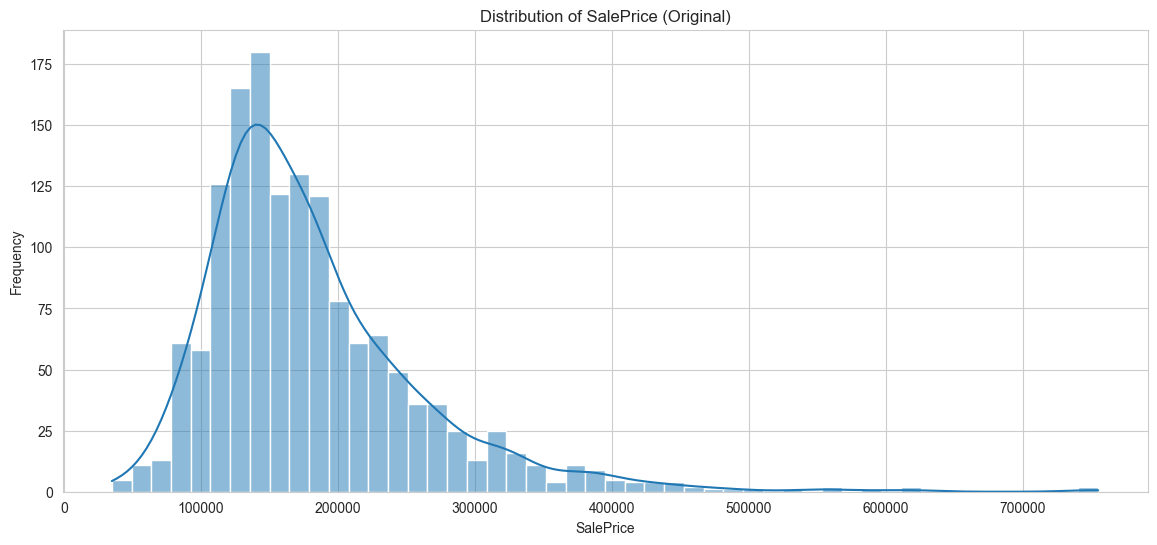

Skewness of SalePrice: 1.8829


In [15]:
# Distribution of the raw SalePrice
plt.figure(figsize=(14, 6))
sns.histplot(train_df['SalePrice'], bins=50, kde=True)
plt.title('Distribution of SalePrice (Original)')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

print(f'Skewness of SalePrice: {train_df["SalePrice"].skew():.4f}')

**Positively skewed — long tail to the right.**

- There is a long tail of expensive houses that can skew model predictions.
- Linear Regression is sensitive to outliers; a skewed target leads to poor performance.

**Fix:** Apply a **log transformation** (`np.log1p`) to compress the range of large values and make the distribution approximately normal.

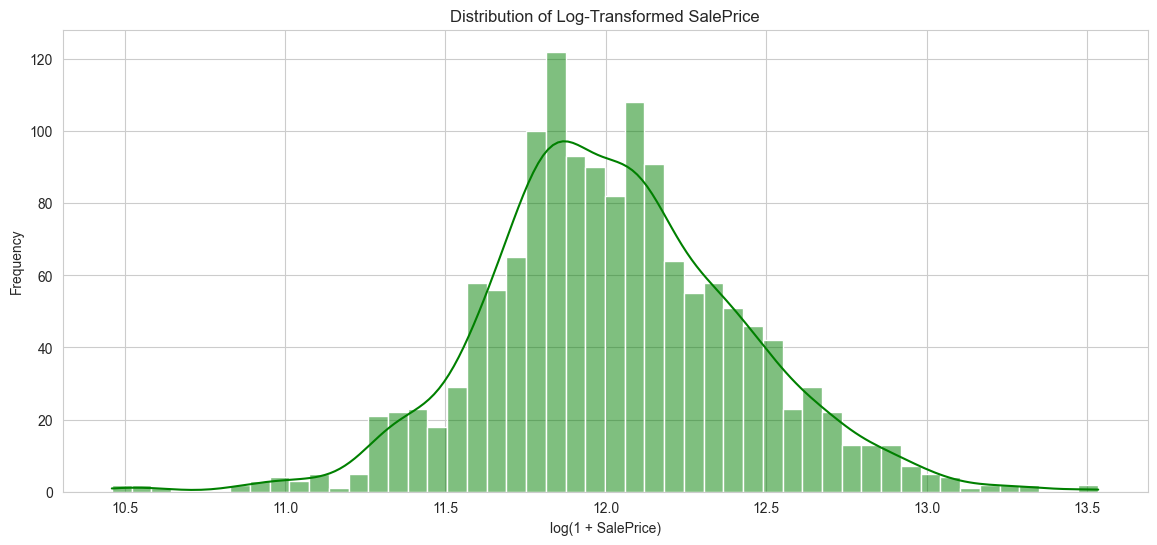

Skewness after log transform: 0.1213


In [16]:
# Apply log transformation to the target variable
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

# Distribution after transformation
plt.figure(figsize=(14, 6))
sns.histplot(train_df['SalePrice'], bins=50, kde=True, color='green')
plt.title('Distribution of Log-Transformed SalePrice')
plt.xlabel('log(1 + SalePrice)')
plt.ylabel('Frequency')
plt.show()

print(f'Skewness after log transform: {train_df["SalePrice"].skew():.4f}')

**Observation:** After the log transformation the distribution is much closer to normal. Skewness is now near 0 — the model will predict `log(price)` and we will reverse the transformation at prediction time with `np.expm1`.

## Step 4: EDA — Feature Variables

Identifying which features have the strongest relationship with our target variable.

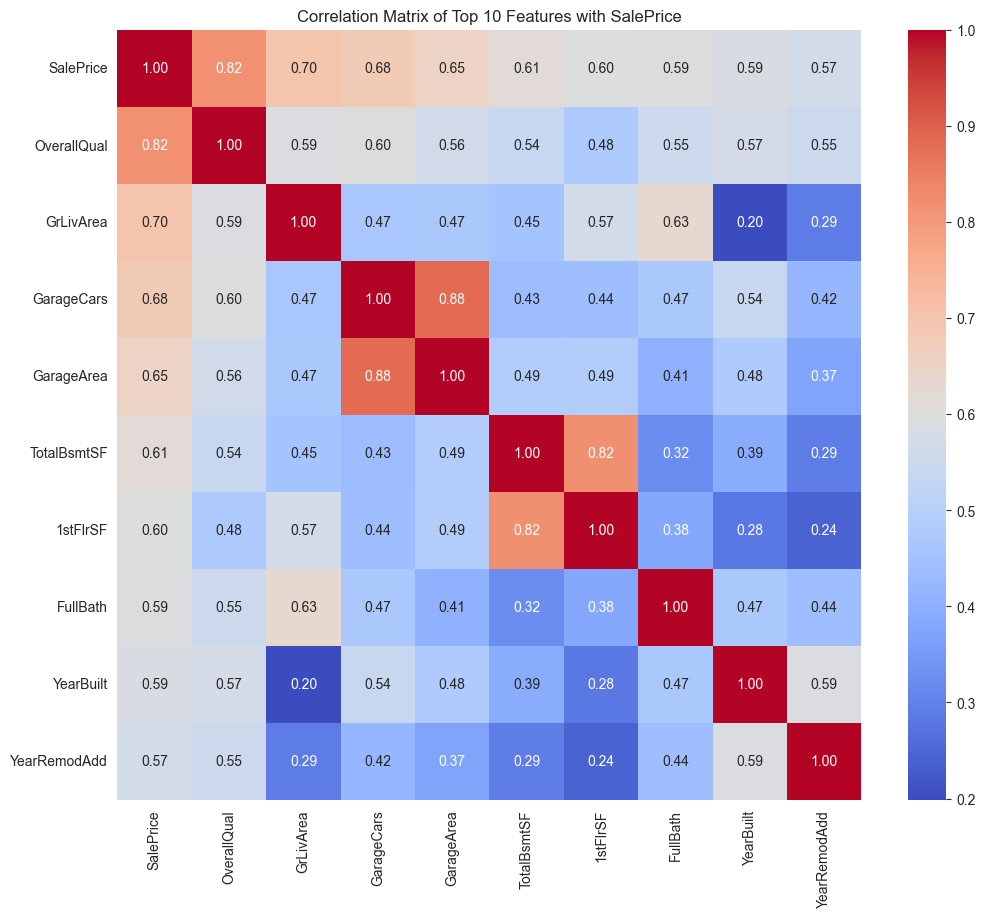

In [17]:
# Top 10 features most correlated with SalePrice
corrmat = train_df.corr(numeric_only=True)
top_corr_features = corrmat.nlargest(10, 'SalePrice')['SalePrice'].index
top_corr_matrix = train_df[top_corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Top 10 Features with SalePrice')
plt.show()

**Insight:** `OverallQual`, `GrLivArea`, and `GarageCars`/`GarageArea` are the most positively correlated features with `SalePrice`. This is intuitive — better quality, larger homes with bigger garages command higher prices.

## Step 5: Data Preprocessing & Feature Engineering

We combine train and test data before preprocessing so every transformation is applied consistently, preventing data leakage.

### 5.1 Combine Train & Test Data

In [18]:
# Combine train and test for consistent preprocessing
all_data = pd.concat((train_df.loc[:, :'SaleCondition'],
                      test_df.loc[:,  :'SaleCondition']))

print(f'Combined data shape: {all_data.shape}')

Combined data shape: (2919, 79)


### 5.2 Handling Missing Values

In [19]:
# Overview of missing values
missing_data = all_data.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]
print(f'Features with missing values: {len(missing_data)}')
print(missing_data)

Features with missing values: 34
PoolQC          2909
MiscFeature     2814
Alley           2721
Fence           2348
MasVnrType      1766
FireplaceQu     1420
LotFrontage      486
GarageCond       159
GarageFinish     159
GarageYrBlt      159
GarageQual       159
GarageType       157
BsmtExposure      82
BsmtCond          82
BsmtQual          81
BsmtFinType2      80
BsmtFinType1      79
MasVnrArea        23
MSZoning           4
BsmtHalfBath       2
Functional         2
BsmtFullBath       2
Utilities          2
Exterior1st        1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF1         1
SaleType           1
KitchenQual        1
GarageCars         1
GarageArea         1
Electrical         1
Exterior2nd        1
BsmtFinSF2         1
dtype: int64


In [20]:
# --- Numerical: fill with 0 (absence of feature) ---
numerical_cols_to_impute_zero = [
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'GarageCars', 'GarageArea', 'BsmtFullBath', 'BsmtHalfBath'
]
for col in numerical_cols_to_impute_zero:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

print('Null counts after zero-imputation:')
print(all_data[numerical_cols_to_impute_zero].isnull().sum())

Null counts after zero-imputation:
MasVnrArea      0
BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
GarageCars      0
GarageArea      0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64


#### LotFrontage — Neighborhood Median Imputation

Houses in the same neighbourhood tend to have similar lot frontage, so we impute missing values using the **median of each neighbourhood group** rather than a global median.

In [21]:
print(f'LotFrontage missing before imputation: {all_data["LotFrontage"].isnull().sum()}')

if 'LotFrontage' in all_data.columns and all_data['LotFrontage'].isnull().any():
    all_data['LotFrontage'] = (
        all_data.groupby('Neighborhood')['LotFrontage']
               .transform(lambda x: x.fillna(x.median()))
    )

print(f'LotFrontage missing after imputation : {all_data["LotFrontage"].isnull().sum()}')

LotFrontage missing before imputation: 486
LotFrontage missing after imputation : 0


In [22]:
# Quick checks on other categorical columns
print('Fence null count :', all_data['Fence'].isnull().sum())
print('Alley value counts:')
print(all_data['Alley'].value_counts())

Fence null count : 2348
Alley value counts:
Alley
Grvl    120
Pave     78
Name: count, dtype: int64


In [23]:
# --- Categorical: fill 'None' where NA means 'feature absent' ---
categorical_cols_to_impute_none = [
    'Alley', 'Fence', 'MiscFeature', 'PoolQC', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
for col in categorical_cols_to_impute_none:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

# Fill with mode where NA means 'data missing'
mode_cols = ['Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd',
             'SaleType', 'Utilities', 'Functional', 'MSZoning']
for col in mode_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

# GarageYrBlt: 0 means no garage, consistent with GarageArea/Cars = 0
if 'GarageYrBlt' in all_data.columns:
    all_data['GarageYrBlt'] = all_data['GarageYrBlt'].fillna(0)

print('Missing values after all imputation:', all_data.isnull().sum().sum())

Missing values after all imputation: 0


### 5.3 Feature Engineering

We create three domain-informed features that are likely to have high predictive power:

- **`TotalSF`** — total square footage across all floors
- **`TotalBath`** — weighted total bathrooms (half-baths count 0.5)
- **`Age`** — age of the house at time of sale

In [24]:
# Total square footage
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

# Total bathrooms (half-baths weighted at 0.5)
all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                         all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

# Age of the house at time of sale
all_data['Age'] = all_data['YrSold'] - all_data['YearBuilt']

print('New engineered features created: TotalSF, TotalBath, Age')

New engineered features created: TotalSF, TotalBath, Age


### 5.4 Categorical Encoding
One-hot encode all remaining object-type columns.

In [25]:
categorical_cols = all_data.select_dtypes(include=['object']).columns
all_data = pd.get_dummies(all_data, columns=categorical_cols, drop_first=True)

print(f'Data shape after one-hot encoding: {all_data.shape}')

C:\Users\sudwa\AppData\Local\Temp\ipykernel_16584\978919375.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = all_data.select_dtypes(include=['object']).columns


Data shape after one-hot encoding: (2919, 262)


## Step 6: Model Building & Training

In [26]:
# Separate back into train / test splits
X            = all_data[:len(train_df)]
y            = train_df['SalePrice']   # already log-transformed
X_test_final = all_data[len(train_df):]

# Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test_final: {X_test_final.shape}')

X_train: (1168, 262) | X_val: (292, 262) | X_test_final: (1459, 262)


### Feature Scaling

Linear models require standardised features (mean = 0, std = 1) to prevent large-scale features like `GrLivArea` from dominating small-scale ones like `OverallQual`. Tree-based models like XGBoost do **not** require scaling, so we use unscaled data for XGBoost.

In [28]:
scaler = StandardScaler()
X_train_scaled     = scaler.fit_transform(X_train)
X_val_scaled       = scaler.transform(X_val)
X_test_final_scaled = scaler.transform(X_test_final)

X_train_scaled

array([[-0.8667643 , -0.01933867, -0.21289571, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 0.07410996, -0.50039047, -0.26524463, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.63154574, -0.15053462, -0.17784146, ..., -0.12510865,
         0.46001984, -0.30263639],
       ...,
       [-0.8667643 , -0.45665849, -0.23409563, ..., -0.12510865,
         0.46001984, -0.30263639],
       [-0.16110861, -0.6753184 , -0.28337613, ..., -0.12510865,
         0.46001984, -0.30263639],
       [ 1.48542135, -0.76278236, -0.65139925, ..., -0.12510865,
         0.46001984, -0.30263639]], shape=(1168, 262))

### 6.1 Model 1: Linear Regression (Baseline)

- Supervised learning algorithm for predicting a continuous target.
- Finds the best-fit line minimising the sum of squared residuals.
- Simple and interpretable — useful as a baseline to benchmark against.

In [29]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)

print('Linear Regression trained.')

Linear Regression trained.


### 6.2 Model 2: XGBoost (Advanced)

- Gradient boosting algorithm that builds trees sequentially.
- Each new tree corrects the errors made by all previous trees.
- Excellent on tabular/structured data with mixed feature types.
- Hyperparameters used: `n_estimators=1000`, `learning_rate=0.05`, `max_depth=3`.

In [30]:
xgbr = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# XGBoost does not require feature scaling — use unscaled data
xgbr.fit(X_train, y_train)
y_pred_xgb = xgbr.predict(X_val)

print('XGBoost trained.')

XGBoost trained.


## Step 7: Model Evaluation

| Metric | Description |
|---|---|
| **RMSE** | √MSE — same units as target; penalises large errors more |
| **MAE** | Average absolute error; easy to interpret |
| **R²** | Proportion of variance explained; closer to 1 = better fit |

In [31]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {model_name} Performance ---')
    print(f'RMSE      : {rmse:.4f}')
    print(f'MAE       : {mae:.4f}')
    print(f'R-squared : {r2:.4f}\n')

evaluate_model(y_val, y_pred_lr,  'Linear Regression')
evaluate_model(y_val, y_pred_xgb, 'XGBoost')

--- Linear Regression Performance ---
RMSE      : 0.1734
MAE       : 0.0960
R-squared : 0.8389

--- XGBoost Performance ---
RMSE      : 0.1322
MAE       : 0.0841
R-squared : 0.9063



**Observation:** XGBoost significantly outperforms Linear Regression on all metrics — lower RMSE/MAE and a higher R². This is expected: gradient boosting captures complex, non-linear relationships that a linear model cannot.

## Step 8: Generate Submission File

In [32]:
# Predict on final test set with XGBoost (best model)
final_predictions_log = xgbr.predict(X_test_final)

# Reverse the log transformation to get back to original price scale
final_predictions = np.expm1(final_predictions_log)

# Build and save the submission DataFrame
submission = pd.DataFrame({'Id': test_df.index, 'SalePrice': final_predictions})
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")
submission.head()

Submission file 'submission.csv' created successfully.


,Id,SalePrice
0,1461,124144.304688
1,1462,163331.750000
2,1463,188116.875000
3,1464,195748.921875
4,1465,176206.109375


## Step 9: Conclusion

In this project we built an end-to-end regression pipeline to predict house prices using the Ames Housing dataset.

**Key Steps:**

1. **Target transformation** — Applied `log1p` to `SalePrice` to reduce skewness and improve model performance.
2. **EDA** — Identified the top features correlated with price (`OverallQual`, `GrLivArea`, `GarageArea`).
3. **Preprocessing** — Handled numerical (zero-fill), categorical (None/mode), and neighbourhood-grouped (LotFrontage) missing values.
4. **Feature engineering** — Created `TotalSF`, `TotalBath`, and `Age` to add predictive signal.
5. **Encoding** — One-hot encoded all categorical variables for model compatibility.
6. **Modelling** — Trained a baseline Linear Regression and an advanced XGBoost model.
7. **Evaluation** — XGBoost outperformed on RMSE, MAE, and R².
8. **Submission** — Reversed the log transform and saved predictions to `submission.csv`.

**Possible next steps:** Ridge/Lasso regularization, stacking/ensembling, further hyperparameter tuning with cross-validation.